In [1]:
#Loading the dataset
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading the dataset
df = pd.read_csv("walmart_processed_data.csv")
df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Month,Week,Day,Is_Holiday_Season,lag_1w,lag_4w,lag_52w,Rolling_4W_Mean,Rolling_12W_Mean,Total_MarkDown
0,1,1,2010-02-05,24924.50,0,42.31,2.572,0.00,0.00,0.00,...,2,5,5,0,0.00,0.00,0.00,0.0000,0.000000,0.00
1,1,1,2010-02-12,46039.49,1,38.51,2.548,0.00,0.00,0.00,...,2,6,12,0,24924.50,0.00,0.00,0.0000,0.000000,0.00
2,1,1,2010-02-19,41595.55,0,39.93,2.514,0.00,0.00,0.00,...,2,7,19,0,46039.49,0.00,0.00,0.0000,0.000000,0.00
3,1,1,2010-02-26,19403.54,0,46.63,2.561,0.00,0.00,0.00,...,2,8,26,0,41595.55,0.00,0.00,0.0000,0.000000,0.00
4,1,1,2010-03-05,21827.90,0,46.50,2.625,0.00,0.00,0.00,...,3,9,5,0,19403.54,24924.50,0.00,32990.7700,0.000000,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
421565,45,98,2012-09-28,508.37,0,64.88,3.997,4556.61,20.64,1.50,...,9,39,28,0,467.30,346.04,727.05,442.9350,565.753333,9468.01
421566,45,98,2012-10-05,628.10,0,64.89,3.985,5046.74,0.00,18.82,...,10,40,5,0,508.37,352.44,894.98,483.5175,553.146667,9659.00
421567,45,98,2012-10-12,1061.02,0,54.47,4.000,1956.28,0.00,7.89,...,10,41,12,0,628.10,605.96,996.40,552.4325,547.554167,6554.03
421568,45,98,2012-10-19,760.01,0,56.47,3.969,2004.02,0.00,3.18,...,10,42,19,0,1061.02,467.30,1058.84,666.1975,565.530833,3982.42


In [3]:
#Train on data before April 2012, test on data from April 2012 onwards
df["Date"] = pd.to_datetime(df["Date"])
cutoff = pd.Timestamp("2012-04-01")
 
train_df = df[df["Date"] < cutoff].copy()
test_df  = df[df["Date"] >= cutoff].copy()
 
print("Training set:", train_df.shape, "Time", train_df.Date.min().date(), "to", train_df.Date.max().date())
print("Test set:", test_df.shape, "Time", test_df.Date.min().date(), "to", test_df.Date.max().date())

Training set: (332778, 28) Time 2010-02-05 to 2012-03-30
Test set: (88792, 28) Time 2012-04-06 to 2012-10-26


In [4]:
#Prepare features and target
X_train = train_df.drop(["Weekly_Sales", "Date"], axis=1)
y_train = train_df["Weekly_Sales"]

X_test = test_df.drop(["Weekly_Sales", "Date"], axis=1)
y_test = test_df["Weekly_Sales"]

In [5]:
#Train a simple linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
#import joblib

lr_pipeline = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])

lr_pipeline.fit(X_train, y_train)
lr_predictions = lr_pipeline.predict(X_test)

#Clip negative predictions to 0 (sales can't be negative)
lr_predictions = lr_predictions.clip(min=0)
 
print("Linear Regression trained")


Linear Regression trained


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)
lr_predictions = model.predict(X_test_scaled)

In [6]:
#Evaluate the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, lr_predictions)
rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Performance")
print("Mean Absolute Error (MAE):", f"{mae:.2f}")
print("Root Mean Squared Error (RMSE):", f"{rmse:.2f}")
print("R2 Score:", f"{r2:.4f}")

Linear Regression Performance
Mean Absolute Error (MAE): 1748.18
Root Mean Squared Error (RMSE): 3204.91
R2 Score: 0.9759


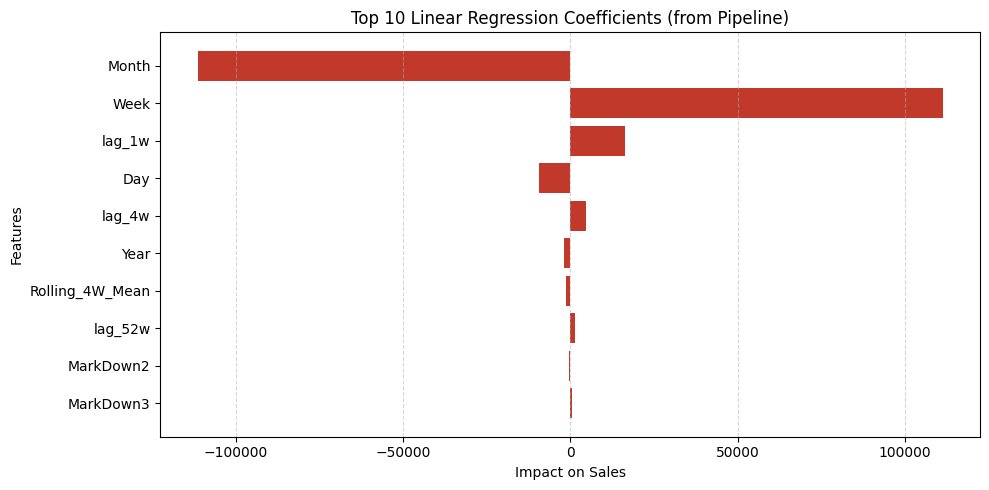

In [7]:
#Important features from linear regression using pipeline
lr_model_extracted = lr_pipeline.named_steps["model"]

lr_coefficients = pd.DataFrame({"Feature": X_train.columns, "Coefficient": lr_model_extracted.coef_})

lr_coefficients["Abs_Coefficient"] = lr_coefficients["Coefficient"].abs()
lr_coefficients = lr_coefficients.sort_values(by="Abs_Coefficient", ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(lr_coefficients["Feature"].head(10), lr_coefficients["Coefficient"].head(10), color='#C0392B')
plt.title("Top 10 Linear Regression Coefficients (from Pipeline)")
plt.xlabel("Impact on Sales")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [8]:
#Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=10, n_jobs=-1, random_state=42)

rf_model = rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)
rf_predictions = rf_predictions.clip(min=0)

print("Random Forest Regressor trained")

Random Forest Regressor trained


In [9]:
# Random Forest Evaluation
mae_rf = mean_absolute_error(y_test, rf_predictions)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_predictions))
r2_rf = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print(f"Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_rf:.2f}")
print(f"R2 Score: {r2_rf:.4f}")

#Comparison of both models
print(f"\nDifference in MAE: {mae - mae_rf:.2f}") 

Random Forest Performance
Mean Absolute Error (MAE): 1248.14
Root Mean Squared Error (RMSE): 2708.76
R2 Score: 0.9828

Difference in MAE: 500.05


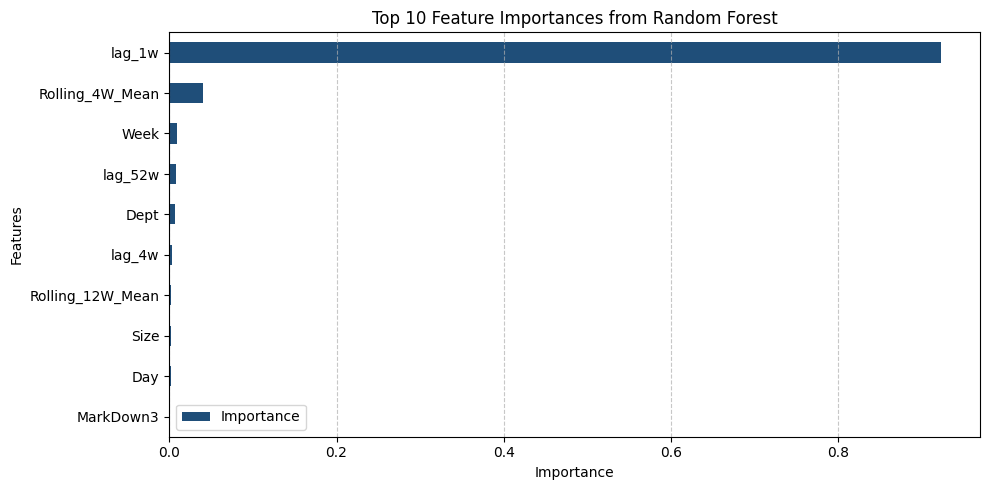

In [10]:
#Feature importance from Random Forest
importances = rf_model.feature_importances_
feature_names = X_train.columns
features_importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})
features_importance_df = features_importance_df.sort_values(by = "Importance", ascending = False)

top_features = features_importance_df.head(10)
top_features.plot(kind = "barh", x = "Feature", y = "Importance", color = "#1F4E79", figsize = (10, 5))
plt.title("Top 10 Feature Importances from Random Forest")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--",alpha=0.7)
plt.tight_layout()
plt.show()


In [11]:
#XGBoost MOdel
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, subsample=0.8, colsample_bytree=0.8,
                         n_jobs=-1, tree_method="hist")

xgb_model.fit(X_train, y_train)

xgb_predictions = xgb_model.predict(X_test)
xgb_predictions = xgb_predictions.clip(min=0)
print("XGBoost Model trained")


XGBoost Model trained


In [12]:
#XGBoost Evaluation
mae_xgb = mean_absolute_error(y_test, xgb_predictions)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_predictions))
r2_xgb = r2_score(y_test, xgb_predictions)

print("XGBoost Performance")
print(f"Mean Absolute Error (MAE): {mae_xgb:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse_xgb:.2f}")
print(f"R2 Score: {r2_xgb:.4f}")

#Comparison of models
print(f"\nDifference in MAE: {mae_xgb - mae_rf:.2f}") 
print(f"Difference in RMSE: {rmse_xgb - rmse_rf:.2f}")

XGBoost Performance
Mean Absolute Error (MAE): 1276.85
Root Mean Squared Error (RMSE): 2706.38
R2 Score: 0.9828

Difference in MAE: 28.72
Difference in RMSE: -2.38


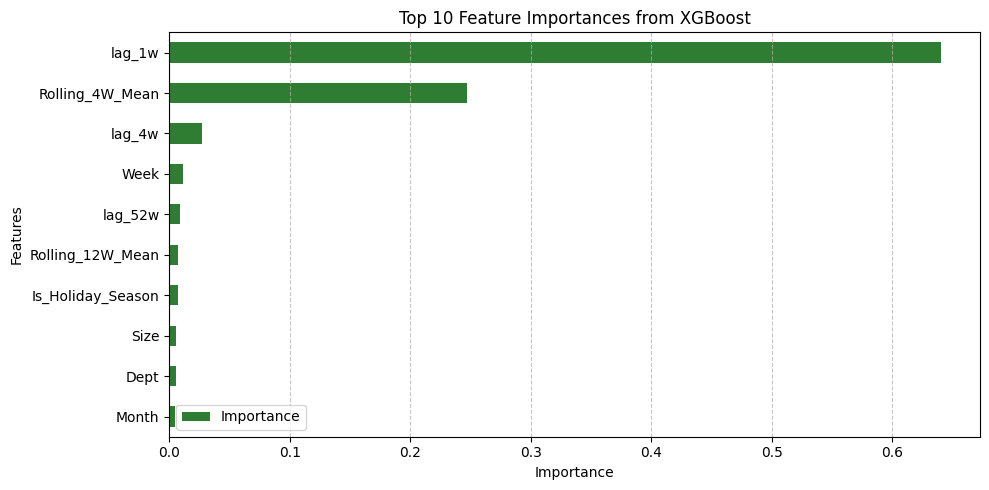

In [13]:
#XGBoost Feature Importance
xgb_importances = xgb_model.feature_importances_
xgb_feature_names = X_train.columns
xgb_importance_df = pd.DataFrame({"Feature": xgb_feature_names, "Importance": xgb_importances})
xgb_importance_df = xgb_importance_df.sort_values(by="Importance", ascending=False)
xgb_top_features = xgb_importance_df.head(10)
xgb_top_features.plot(kind="barh", x="Feature", y="Importance", color="#2E7D32", figsize=(10, 5))
plt.title("Top 10 Feature Importances from XGBoost")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--",alpha=0.7)
plt.tight_layout()
plt.show()

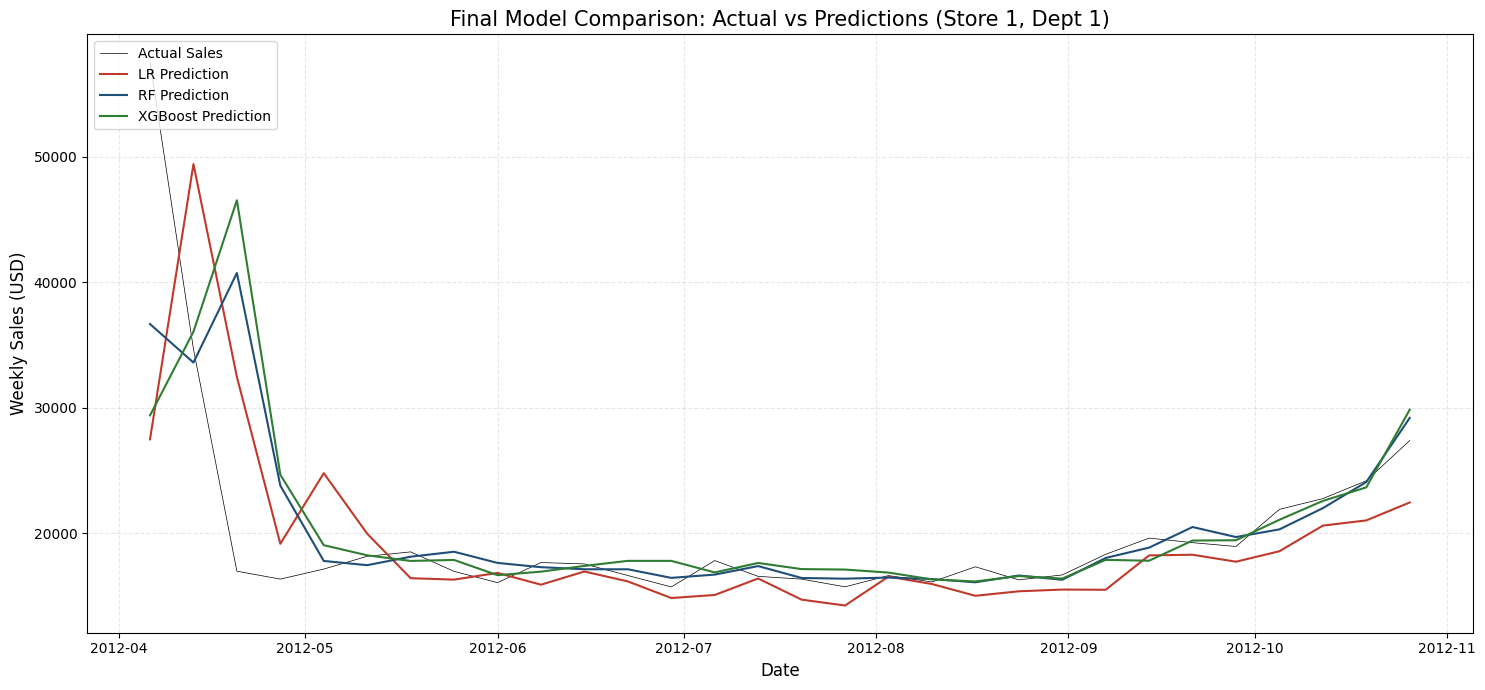

In [14]:
#VIsualization of predictions vs actual sales for Store 1, Dept 1
FEATURE_COLS = [col for col in X_train.columns]
sample = test_df[(test_df["Store"] == 1) & (test_df["Dept"] == 1)].copy()

sample_lr_preds = lr_pipeline.predict(sample[FEATURE_COLS]).clip(min=0)
sample_rf_preds = rf_model.predict(sample[FEATURE_COLS])
sample_xgb_preds = xgb_model.predict(sample[FEATURE_COLS])

plt.figure(figsize=(15, 7))
plt.plot(sample["Date"], sample["Weekly_Sales"], label="Actual Sales", color="Black", linewidth=0.5)
plt.plot(sample["Date"], sample_lr_preds, label="LR Prediction", color="#C0392B")
plt.plot(sample["Date"], sample_rf_preds, label="RF Prediction", color="#1F4E79")
plt.plot(sample["Date"], sample_xgb_preds, label="XGBoost Prediction", color="#2E7D32")

plt.title("Final Model Comparison: Actual vs Predictions (Store 1, Dept 1)", fontsize=15)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Weekly Sales (USD)", fontsize=12)
plt.legend(loc="upper left", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

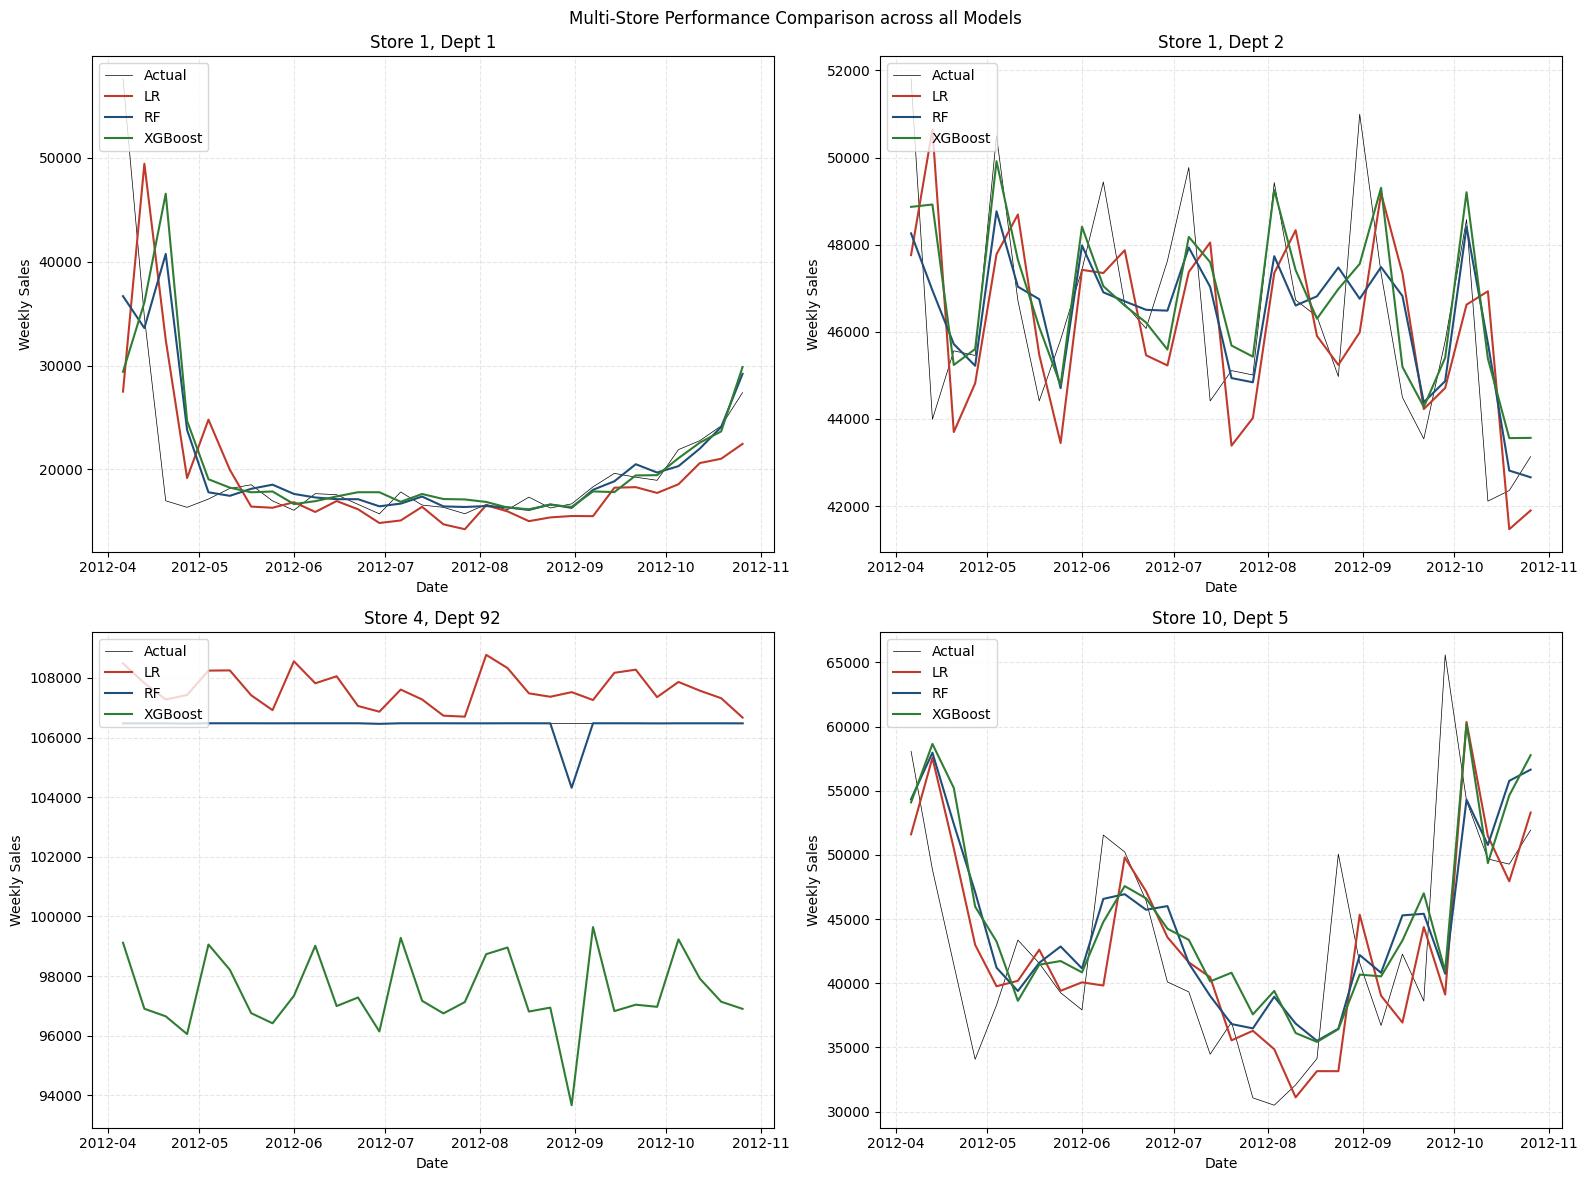

In [15]:
#Multiple store-department combinations to visualize
FEATURE_COLS = [col for col in X_train.columns]

combos = [(1,1), (1,2), (4,92), (10,5)]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (s, d) in enumerate(combos):
    temp = test_df[(test_df["Store"] == s) & (test_df["Dept"] == d)].copy()
    
    temp_lr = lr_pipeline.predict(temp[FEATURE_COLS]).clip(min=0)
    temp_rf = rf_model.predict(temp[FEATURE_COLS])
    temp_xgb = xgb_model.predict(temp[FEATURE_COLS])
    
    axes[i].plot(temp["Date"], temp["Weekly_Sales"], label="Actual", color="Black", linewidth=0.5)
    
    axes[i].plot(temp["Date"], temp_lr, label="LR", color="#C0392B")
    
    axes[i].plot(temp["Date"], temp_rf, label="RF", color="#1F4E79")
    
    axes[i].plot(temp["Date"], temp_xgb, label="XGBoost", color="#2E7D32")
    
    axes[i].set_title(f"Store {s}, Dept {d}")
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Weekly Sales")
    axes[i].legend(loc="upper left")
    axes[i].grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Multi-Store Performance Comparison across all Models")
plt.tight_layout()
plt.show()

In [32]:
#Saving the models
import joblib

joblib.dump((lr_pipeline, lr_predictions), "walmart_lr.joblib")
joblib.dump((rf_model, rf_predictions), "walmart_rf.joblib")
joblib.dump((xgb_model, xgb_predictions), "walmart_xgb.joblib")
joblib.dump((train_df, test_df), "data_frame.joblib")
joblib.dump((X_train, y_train, X_test, y_test), "data_splits.joblib")

print("Models saved successfully!")

Models saved successfully!
